In [1]:
# %matplotlib inline
%time from hikyuu.interactive import *
from pylab import plot

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:39:36.052 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:39:37,747 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:39:37,748 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:39:37.760 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:39:37.821 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:39:37.854 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:39:37.865 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:39:37.875 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:39:38.017 [HKU-I] - 加载权息数据…… (StockManager.cpp:1170)
2026-09-25 13:39:38.281 [HKU-I] - 加载板块信息…… (StockManager.cpp:214)
2026-09-25 13:39:38.425 [HKU-I] - 加载K线数据…… (StockManager.cpp:221)
2026-09-25 13:39:38.425 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:395)
2026-09-25 13:39:38.426 [HKU-I] - 0.59 秒数据加载完毕. (StockManager.cpp:231)
CPU times: user 2.47 s, sys: 235 ms, total: 2.71 s
Wall time: 3.67 s


In [2]:
# Create a system strategy
# my_mm = MM_FixedCount(100)
my_mm = MM_Nothing()
my_sg = SG_Flex(EMA(CLOSE(), n=5), slow_n=10)
my_sys = SYS_Simple(sg=my_sg, mm=my_mm)

In [3]:
# Create a selector algorithm to select the trading system every day
# This is a fixed selector, i.e. the specified trading system is selected every day
# my_se = SE_Fixed([s for s in blocka if s.valid], my_sys)
my_se = SE_Fixed([s for s in sm.get_block("指数板块", "沪深300")], my_sys)

In [4]:
# Create an asset allocator to determine how to allocate the assets among the selected trading systems
# This creates an equal-weight asset allocator, i.e. allocating the funds among the selected systems with the same ratio
my_af = AF_EqualWeight()

In [5]:
# Create the portfolio
# Create an account starting from 2001-01-01 with an initial capital of 2,000,000. Since an equal-weight allocator is used, the remaining funds of the account are allocated equally among all the selected systems,
# If the initial capital is too small, each system will not have enough funds to complete the trades.
my_tm = crtTM(Datetime(200101010000), 2000000)
my_pf = PF_Simple(tm=my_tm, af=my_af, se=my_se)

In [6]:
# Run the portfolio
q = Query(-500)
%time my_pf.run(Query(-500), 10)

CPU times: user 1.71 s, sys: 635 ms, total: 2.35 s
Wall time: 6.33 s


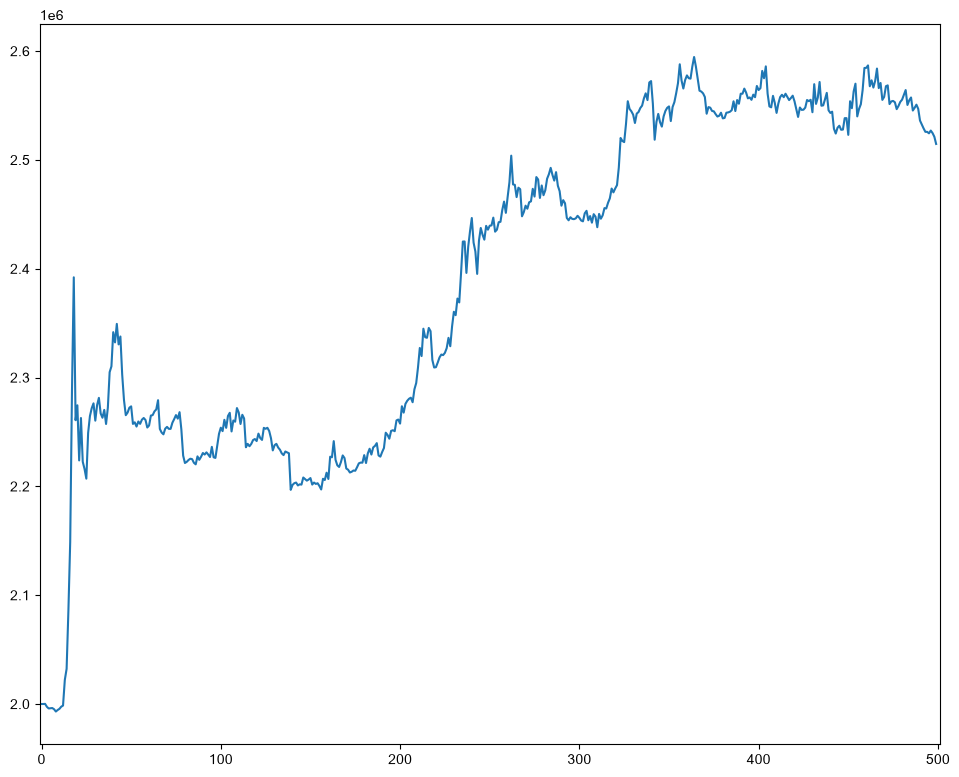

In [7]:
x = my_tm.get_funds_curve(sm.get_trading_calendar(q))
PRICELIST(x).plot()

<Axes: title={'center': '账户(SYS) 累积收益率'}>

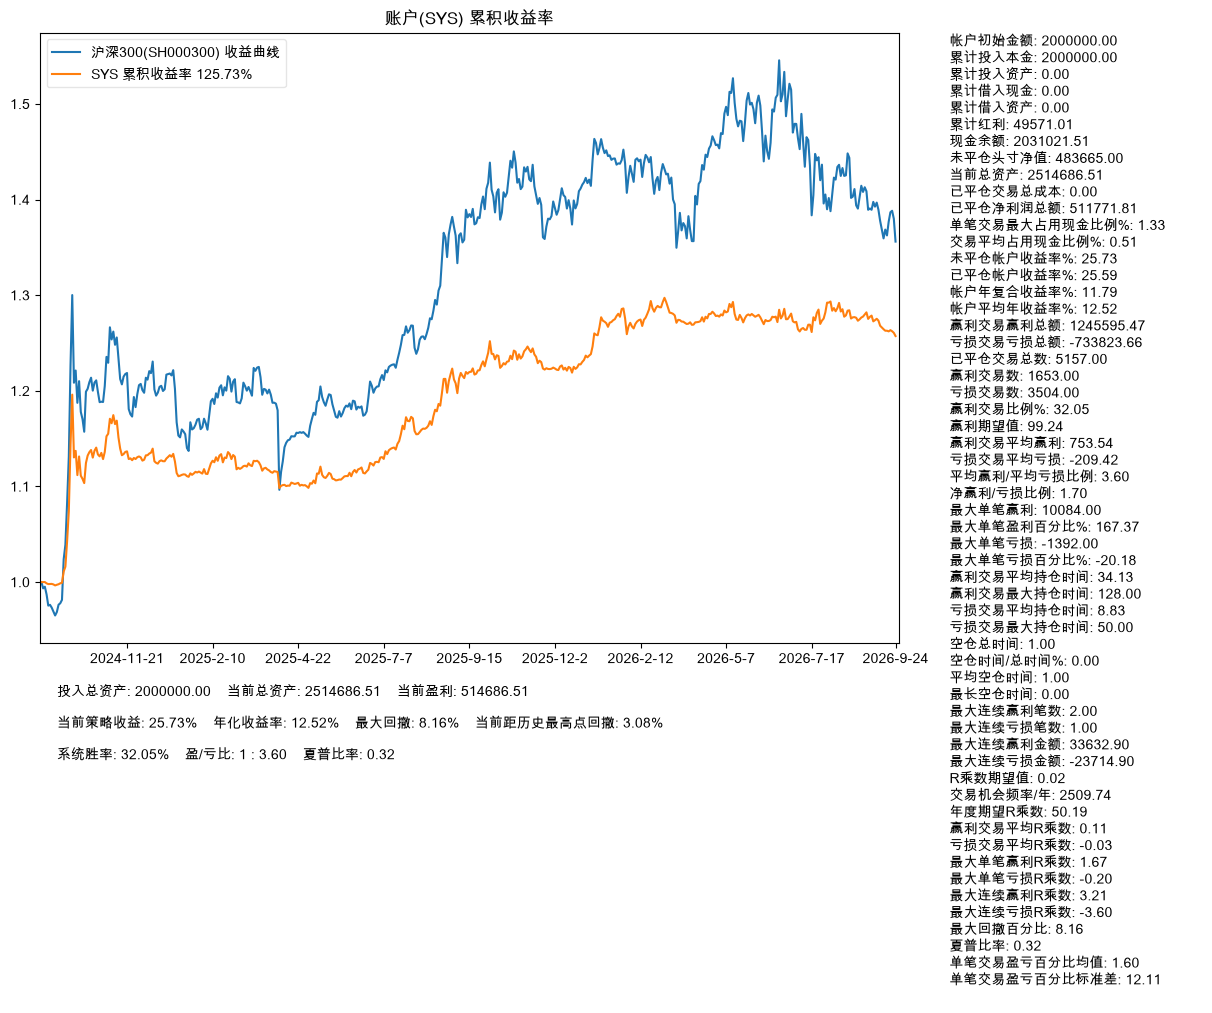

In [8]:
my_pf.performance()

In [9]:
my_tm

TradeManager {
  params: params[precision(int): 2, save_action(bool): 1, support_borrow_cash(bool): 0, support_borrow_stock(bool): 0, ],
  name: SYS,
  init_date: 2001-01-01 00:00:00,
  init_cash: 2000000.00,
  firstDatetime: 2024-09-05 00:00:00,
  lastDatetime: 2026-09-24 00:00:00,
  TradeCostFunc: TradeCostFunc(TC_Zero, params[]),
  current total funds: 2514686.51,
  current cash: 2031021.51,
  current market_value: 483665.00,
  current short_market_value: 0.00,
  current base_cash: 2000000.00,
  current base_asset: 0.00,
  current borrow_cash: 0.00,
  current borrow_asset: 0.00,
  Position: 
    证券代码 证券名称 建仓日期 持有天数 持有数量 投入资金 当前市值 当前收益 当前收益率 相对账户初始资金收益率
    SZ000538 云南白药 2026-09-01 00:00:00 18 100.00 4925.20 4987.00 61.80 1.25% 0.00%
    SZ000625 长安汽车 2026-09-22 00:00:00 3 1200.00 8580.00 8436.00 -144.00 -1.68% -0.01%
    SH600023 浙能电力 2026-09-10 00:00:00 11 1700.00 8500.00 8738.00 238.00 2.80% 0.01%
    SH600026 中远海能 2026-08-18 00:00:00 28 400.00 6701.00 8560.00 1859.00 27.74% 0.09%

In [10]:
my_tm.get_position_list().to_df()

,证券代码,证券名称,开仓时间,持有天数,持仓数量,总投入资金,市值,收益,收益百分比,止损,目标价格,清仓时间,累计持仓数量,累计成本,累计风险,累计买入资金,累计卖出资金
0,SZ000538,云南白药,2026-09-01,24,100.0,4925.2,4987.0,61.8,1.25,0.0,NaN,NaT,100.0,0.0,5029.0,5029.0,103.8
1,SZ000625,长安汽车,2026-09-22,3,1200.0,8580.0,8436.0,-144.0,-1.68,0.0,NaN,NaT,1200.0,0.0,8580.0,8580.0,0.0
2,SH600023,浙能电力,2026-09-10,15,1700.0,8500.0,8738.0,238.0,2.80,0.0,NaN,NaT,1700.0,0.0,8500.0,8500.0,0.0
3,SH600026,中远海能,2026-08-18,38,400.0,6701.0,8560.0,1859.0,27.74,0.0,NaN,NaT,500.0,0.0,8910.0,8910.0,2209.0
4,SH600029,南方航空,2026-09-24,1,1700.0,8415.0,8262.0,-153.0,-1.82,0.0,NaN,NaT,1700.0,0.0,8415.0,8415.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,SZ300442,润泽科技,2026-09-23,2,100.0,6601.0,6801.0,200.0,3.03,0.0,NaN,NaT,100.0,0.0,6601.0,6601.0,0.0
60,SZ300450,先导智能,2026-09-21,4,200.0,6478.0,6422.0,-56.0,-0.86,0.0,NaN,NaT,200.0,0.0,6478.0,6478.0,0.0
61,SZ300498,温氏股份,2026-09-22,3,500.0,7465.0,7255.0,-210.0,-2.81,0.0,NaN,NaT,500.0,0.0,7465.0,7465.0,0.0
62,SZ300628,亿联网络,2026-09-16,9,200.0,8080.0,8192.0,112.0,1.39,0.0,NaN,NaT,200.0,0.0,8180.0,8180.0,100.0


In [11]:
my_tm.get_trade_list().to_df()

,证券代码,证券名称,日期,交易操作,计划价格,实际价格,目标价格,数量,止损,现金,总成本,佣金,印花税,过户费,其它成本,来源,备注
0,,,2001-01-01,INIT,2000000.00,2000000.00,0.0,0.0,0.0,2000000.00,0.0,0.0,0.0,0.0,0.0,--,
1,SH600958,东方证券,2024-09-05,BUY,8.48,8.48,NaN,800.0,0.0,1993216.00,0.0,0.0,0.0,0.0,0.0,SG,
2,SH601601,中国太保,2024-09-06,BUY,30.25,30.25,NaN,200.0,0.0,1987166.00,0.0,0.0,0.0,0.0,0.0,SG,
3,SH601916,浙商银行,2024-09-06,BUY,2.55,2.55,NaN,2700.0,0.0,1980281.00,0.0,0.0,0.0,0.0,0.0,SG,
4,SZ300866,安克创新,2024-09-06,BUY,66.55,66.55,NaN,100.0,0.0,1973626.00,0.0,0.0,0.0,0.0,0.0,SG,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11104,SH600104,上汽集团,2026-09-24,SELL,10.83,10.83,NaN,800.0,0.0,2014784.51,0.0,0.0,0.0,0.0,0.0,SG,
11105,SH600886,国投电力,2026-09-24,BUY,14.65,14.65,NaN,500.0,0.0,2007459.51,0.0,0.0,0.0,0.0,0.0,SG,
11106,SH600893,航发动力,2026-09-24,SELL,39.31,39.31,NaN,200.0,0.0,2015321.51,0.0,0.0,0.0,0.0,0.0,SG,
11107,SH601169,北京银行,2026-09-24,SELL,5.48,5.48,NaN,1600.0,0.0,2024089.51,0.0,0.0,0.0,0.0,0.0,SG,
